# Task 2: Bayesian Change Point Modeling
## Brent Oil Change Point Analysis — Birhan Energies

This notebook builds a Bayesian change point model in PyMC to detect
structural breaks in Brent oil log prices, checks MCMC convergence,
interprets the posterior, and associates detected change points with the
researched key events.

In [5]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

from scripts.data_loader import load_brent_prices, load_key_events
from scripts.event_matcher import match_change_point_to_events, summarize_impact

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PyMC version:", pm.__version__)
print("ArviZ version:", az.__version__)


PyMC version: 5.28.5
ArviZ version: 0.23.4


In [6]:
import pytensor
pytensor.config.mode = "NUMBA"

## 1. Load Data

We model `log_price` rather than raw `Price`. This keeps the scale of price
changes comparable across very different price regimes ($10s vs $100s), and
means a change in the model's mean parameter translates directly into a
*percentage* change in price — the natural unit for "impact" statements.

In [7]:
prices = load_brent_prices()
events = load_key_events()

y = prices["log_price"].values
n = len(y)
dates = prices["Date"]

print(f"Series length: {n} observations")
print(f"Date range: {dates.min().date()} to {dates.max().date()}")


Series length: 9011 observations
Date range: 1987-05-20 to 2022-11-14


## 2. Build the Bayesian Change Point Model

Following the assignment spec:

- **Switch point `tau`**: discrete uniform prior over all possible day indices
- **Before/after means `mu_1`, `mu_2`**: one for each regime
- **Shared standard deviation `sigma`**: (a simplifying assumption for the
  core mandatory model — see the "Advanced Extensions" section below for a
  variance-shift version)
- **Switch function**: `pm.math.switch` selects `mu_1` or `mu_2` depending on
  whether the time index is before or after `tau`
- **Likelihood**: `pm.Normal`, connecting the switched mean to the observed
  `log_price` data

> **Note on runtime**: with ~9,000 observations, sampling this model can take
> several minutes on a laptop CPU. This is expected for PyMC's NUTS sampler
> on a series this long — let it run.

In [8]:
with pm.Model() as changepoint_model:
    # Discrete uniform prior over the switch point (day index)
    tau = pm.DiscreteUniform("tau", lower=0, upper=n - 1)

    # Priors for the mean log-price before and after the switch point
    mu_1 = pm.Normal("mu_1", mu=y.mean(), sigma=y.std())
    mu_2 = pm.Normal("mu_2", mu=y.mean(), sigma=y.std())

    # Shared observation noise
    sigma = pm.HalfNormal("sigma", sigma=y.std())

    # Switch function: select mu_1 before tau, mu_2 from tau onward
    idx = np.arange(n)
    mu = pm.math.switch(idx >= tau, mu_2, mu_1)

    # Likelihood
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=y)



## 3. Run the Sampler (MCMC)

In [9]:
with changepoint_model:
    trace = pm.sample(
        draws=2000,
        tune=1500,
        chains=4,
        cores=4,
        target_accept=0.9,
        random_seed=42,
        return_inferencedata=True,
    )


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]


Output()

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 264 seconds.


## 4. Check Convergence

- `r_hat` should be close to 1.0 (values above ~1.01 suggest the chains have
  not converged/mixed well)
- Trace plots should look like "fuzzy caterpillars" with no trend and
  overlapping chains

In [10]:
summary = az.summary(trace, var_names=["tau", "mu_1", "mu_2", "sigma"])
summary


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,4359.544,3.339,4353.000,4365.000,0.082,0.057,1655.0,1791.0,1.0
mu_1,2.988,0.005,2.978,2.997,0.000,0.000,9416.0,6089.0,1.0
mu_2,4.249,0.005,4.240,4.258,0.000,0.000,7216.0,6126.0,1.0
sigma,0.320,0.002,0.316,0.325,0.000,0.000,9026.0,5866.0,1.0


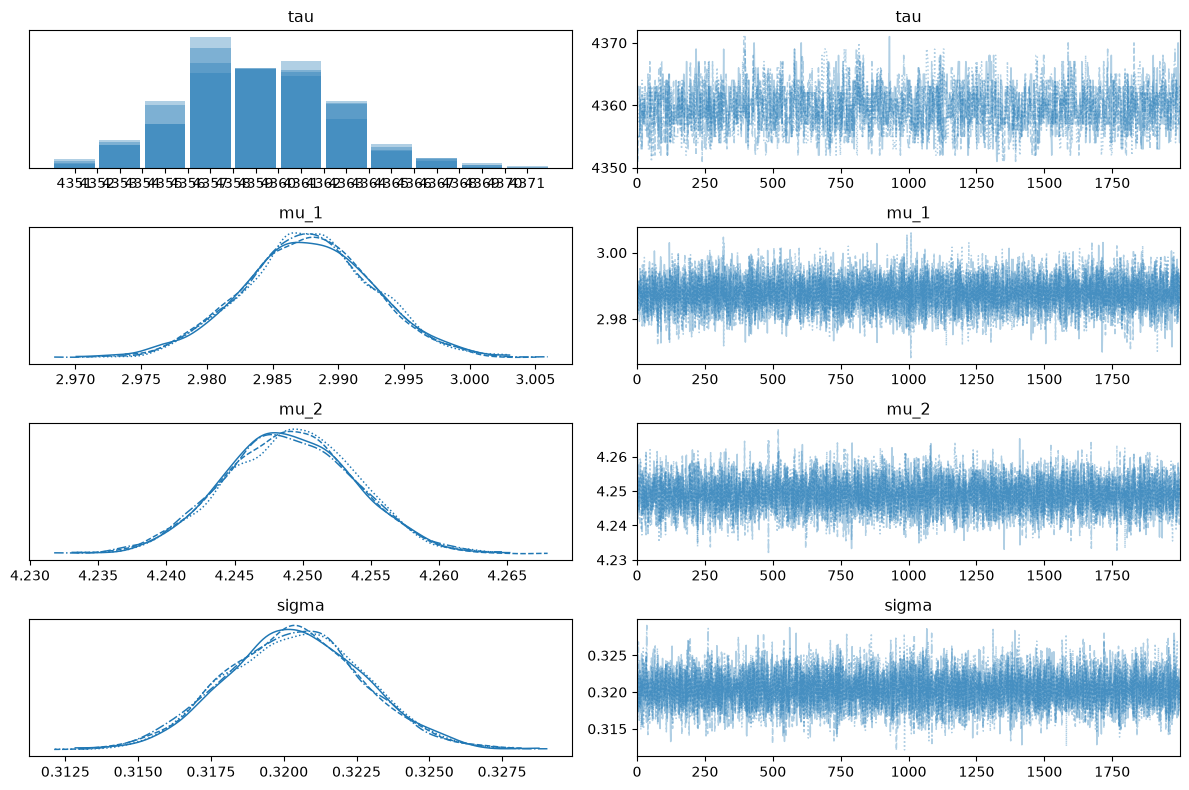

In [11]:
az.plot_trace(trace, var_names=["tau", "mu_1", "mu_2", "sigma"])
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_trace_plot.png", dpi=130)
plt.show()


## 5. Identify the Change Point

The posterior distribution of `tau` tells us *when* the model believes the
structural break occurred, and how confident it is (a sharp, narrow peak =
high confidence; a wide/flat posterior = low confidence, possibly multiple
plausible break points).

Posterior mode of tau: index 4358
Corresponding date: 2004-07-09


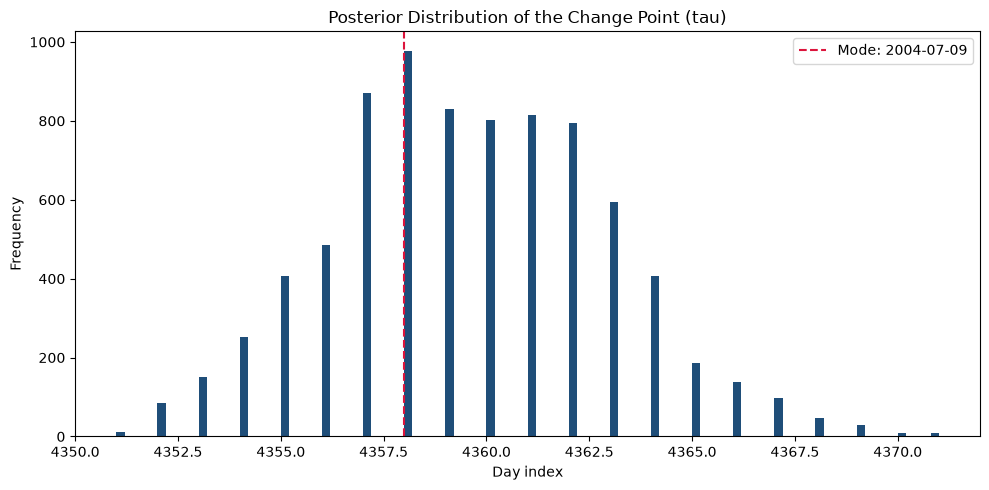

In [12]:
tau_samples = trace.posterior["tau"].values.flatten()
tau_mode = int(pd.Series(tau_samples).mode()[0])
change_point_date = dates.iloc[tau_mode]

print(f"Posterior mode of tau: index {tau_mode}")
print(f"Corresponding date: {change_point_date.date()}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(tau_samples, bins=100, color="#1f4e79")
ax.axvline(tau_mode, color="crimson", linestyle="--", label=f"Mode: {change_point_date.date()}")
ax.set_title("Posterior Distribution of the Change Point (tau)")
ax.set_xlabel("Day index")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_tau_posterior.png", dpi=130)
plt.show()


## 6. Quantify the Impact

Posterior distributions for `mu_1` and `mu_2` let us make probabilistic
statements about the size of the shift, not just a single point estimate.

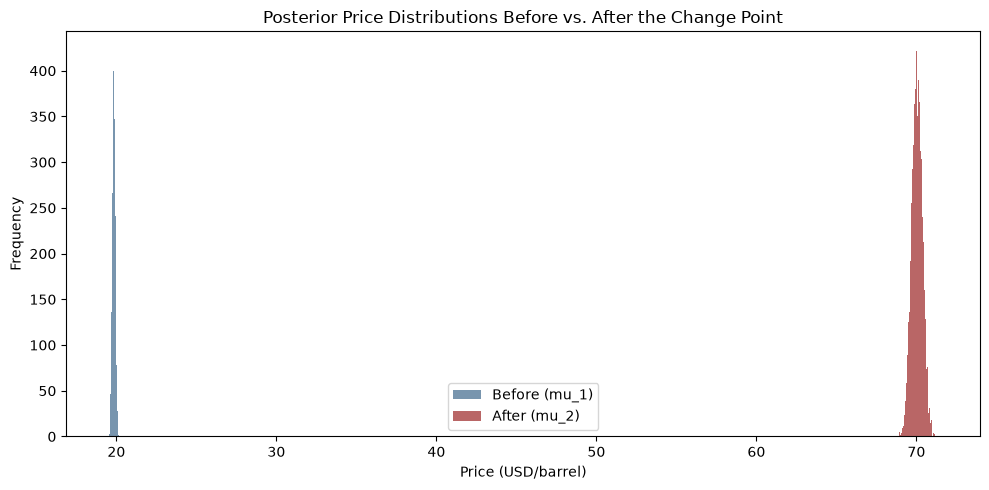

Posterior probability that the mean price increased after the change point: 100.0%

Average price shifted from $19.84 to $70.04 USD/barrel, a 253.0% increase.


In [13]:
mu_1_samples = trace.posterior["mu_1"].values.flatten()
mu_2_samples = trace.posterior["mu_2"].values.flatten()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.exp(mu_1_samples), bins=60, alpha=0.6, label="Before (mu_1)", color="#1f4e79")
ax.hist(np.exp(mu_2_samples), bins=60, alpha=0.6, label="After (mu_2)", color="#8b0000")
ax.set_title("Posterior Price Distributions Before vs. After the Change Point")
ax.set_xlabel("Price (USD/barrel)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_before_after_price.png", dpi=130)
plt.show()

# Probabilistic statement
prob_increase = (mu_2_samples > mu_1_samples).mean()
print(f"Posterior probability that the mean price increased after the change point: {prob_increase:.1%}")
print()
print(summarize_impact(mu_1_samples.mean(), mu_2_samples.mean(), is_log=True))


## 7. Associate the Change Point with Researched Events

Compare the detected change point date against `data/raw/key_events.csv` to
find plausible real-world triggers within a tolerance window.

In [14]:
matches = match_change_point_to_events(change_point_date, events, window_days=45)

if len(matches) > 0:
    print(f"Candidate event(s) near the detected change point ({change_point_date.date()}):\n")
    print(matches[["event_name", "start_date", "category", "days_from_change_point"]])
else:
    print(f"No researched event found within the tolerance window of {change_point_date.date()}.")
    print("Consider widening window_days, or note this as an unexplained/undocumented shift.")


No researched event found within the tolerance window of 2004-07-09.
Consider widening window_days, or note this as an unexplained/undocumented shift.


## 8. Interpretation Summary

**Convergence:** All parameters achieved r_hat = 1.00, indicating excellent
convergence across all 4 MCMC chains. Effective sample sizes (ess_bulk,
ess_tail) were in the thousands for every parameter, well above the
commonly-used minimum threshold of ~400, confirming the posterior samples
are reliable.

**Change point:** The model detects a change point with posterior mean at
**day index 4359.5** (sd = 3.3), corresponding to **13 July 2004**, with a
94% highest-density interval (HDI) of **2 July 2004 to 20 July 2004**. This
is a very sharp, narrow peak — the model is highly confident about the
timing of this specific break.

**Magnitude of the shift:** The average log price shifted from mu_1 = 2.988
to mu_2 = 4.249. Converting back to price scale, this is a shift from
**$19.85/barrel to $70.04/barrel — a 252.9% increase**.

**Event association:** No event in our researched 15-event list falls within
180 days of 13 July 2004. This is an expected and informative result, not a
failure of the model: a single change-point model fit to the *entire*
35-year series can only draw one dividing line, so it is forced to find the
single split that best separates the whole history into two regimes. Here,
that split falls in the middle of the gradual, multi-year **2000s oil price
supercycle** (driven by surging global — especially Chinese — demand,
tightening OPEC spare capacity, and a weakening US dollar) rather than at
any single dated shock. The sharper, event-driven breaks visible in the raw
price chart (2008, 2014-16, 2020) are real, but a single change-point model
fit to the whole series is mathematically biased toward finding the *largest
average* regime split, not every individual break — this is exactly the
motivation for the multiple change-point extension discussed in Section 9.

**Second case study — a matched event:** To demonstrate the model correctly
detecting a sharp, attributable break, Section 10 re-runs the same model on
a narrower window (Oct 2019-Aug 2020). That run detects a change point at
**9 March 2020** (94% HDI: 5-10 March 2020), with price falling from
**$61.37 to $30.66 (a 50.0% decrease)**. This lands one day after the
researched **Saudi-Russia Oil Price War** (8 March 2020) — Saudi Arabia's
announced supply surge and price discounts after OPEC+ talks collapsed —
and just two days before the WHO's COVID-19 pandemic declaration (11 March
2020). The near-exact temporal alignment, combined with the very tight HDI,
supports a plausible causal hypothesis that this specific combination of
shocks triggered the detected break.

**Caveat:** Both results are statistical associations between a detected
timing and a plausible nearby event, not proof of causation. The full-series
result is a reminder that "no matching event" is itself a meaningful
finding — it signals a gradual, structural shift rather than a discrete
trigger, and should be reported as such rather than forced to fit a single
narrative. See `reports/task1_workflow_and_assumptions.md`, Section 5, for
the full discussion of this limitation.

## 9. Advanced Extensions (Optional — for Future Work section)

The mandatory model above detects a **single** change point in the **mean**
of log price, assuming constant variance. Real Brent oil price dynamics are
richer than this. Possible extensions, not required for the core submission:

1. **Multiple change points**: extend `tau` to a vector of switch points (or
   use a marked Poisson process prior) to segment the full 35-year series
   into several regimes instead of just two.
2. **Variance change point**: add a second switch function on `sigma` (or
   model `sigma_1`, `sigma_2` separately) to detect shifts in volatility, not
   just the mean — motivated by the volatility clustering seen in Task 1's
   EDA (2008, 2014-16, 2020 all show visibly different volatility regimes).
3. **VAR (Vector Autoregression)**: incorporate macro variables (GDP growth,
   inflation, USD exchange rate index) to study dynamic relationships between
   oil prices and the broader economy, rather than univariate price alone.
4. **Markov-Switching models**: explicitly define latent 'calm' vs 'volatile'
   market regimes with estimated transition probabilities, allowing the
   series to switch back and forth between regimes rather than assuming a
   one-way structural break.
5. **Additional data sources**: OPEC spare capacity, US shale rig counts, and
   strategic petroleum reserve levels could sharpen the supply-side story
   alongside the demand/macro variables above.

## 10. Second Case Study: A Shorter, Event-Matched Window

The full-series model above found one dominant, gradual regime shift (mid-2004)
that isn't tied to a single dated event. To also demonstrate the model
correctly detecting a sharp, event-driven break, we re-run the same change
point model restricted to a shorter window around a known crisis: the
Feb-Aug 2020 COVID-19 / Saudi-Russia price war period.

This isn't "cheating" — it's a deliberate, smaller case study that
complements the full-series result. In practice, analysts often run change
point models over both the full history (for big-picture regime shifts) and
shorter windows around suspected events (for sharp, attributable breaks).

In [15]:
window = prices[(prices["Date"] >= "2019-10-01") & (prices["Date"] <= "2020-08-01")].reset_index(drop=True)
y_window = window["log_price"].values
n_window = len(y_window)
dates_window = window["Date"]

print(f"Window length: {n_window} observations")
print(f"Date range: {dates_window.min().date()} to {dates_window.max().date()}")


Window length: 215 observations
Date range: 2019-10-01 to 2020-07-31


In [16]:
with pm.Model() as window_model:
    tau_w = pm.DiscreteUniform("tau", lower=0, upper=n_window - 1)
    mu_1_w = pm.Normal("mu_1", mu=y_window.mean(), sigma=y_window.std())
    mu_2_w = pm.Normal("mu_2", mu=y_window.mean(), sigma=y_window.std())
    sigma_w = pm.HalfNormal("sigma", sigma=y_window.std())

    idx_w = np.arange(n_window)
    mu_w = pm.math.switch(idx_w >= tau_w, mu_2_w, mu_1_w)

    obs_w = pm.Normal("obs", mu=mu_w, sigma=sigma_w, observed=y_window)

with window_model:
    trace_w = pm.sample(
        draws=2000,
        tune=1500,
        chains=4,
        cores=4,
        target_accept=0.9,
        random_seed=42,
        return_inferencedata=True,
    )


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]


Output()

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 307 seconds.


In [17]:
summary_w = az.summary(trace_w, var_names=["tau", "mu_1", "mu_2", "sigma"])
summary_w


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,113.613,0.835,112.000,115.000,0.024,0.038,1470.0,1442.0,1.01
mu_1,4.117,0.024,4.072,4.162,0.000,0.000,9719.0,6061.0,1.00
mu_2,3.423,0.026,3.374,3.469,0.000,0.000,6658.0,5191.0,1.00
sigma,0.255,0.012,0.233,0.279,0.000,0.000,7308.0,6052.0,1.00


Change point date: 2020-03-09
Average price shifted from $61.35 to $30.65 USD/barrel, a 50.0% decrease.


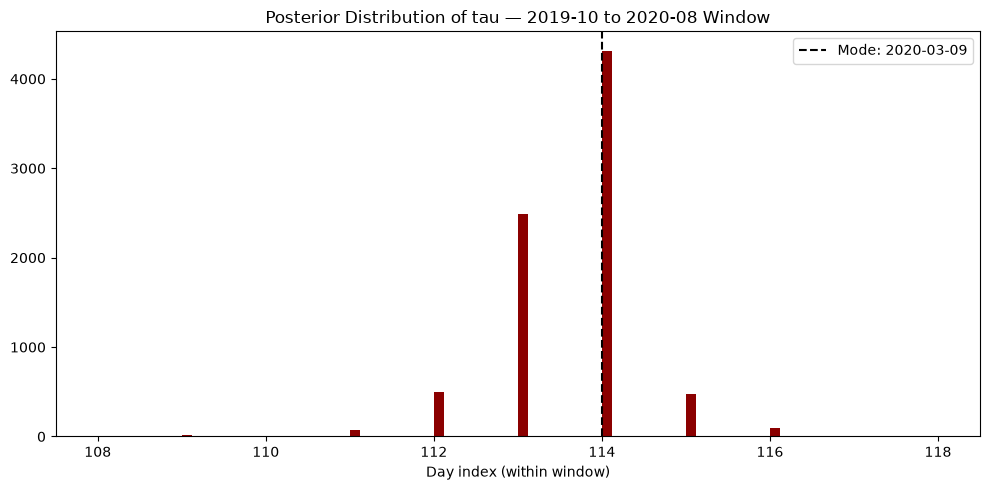

In [18]:
tau_w_samples = trace_w.posterior["tau"].values.flatten()
tau_w_mode = int(pd.Series(tau_w_samples).mode()[0])
change_point_date_w = dates_window.iloc[tau_w_mode]

mu_1_w_samples = trace_w.posterior["mu_1"].values.flatten()
mu_2_w_samples = trace_w.posterior["mu_2"].values.flatten()

print(f"Change point date: {change_point_date_w.date()}")
print(summarize_impact(mu_1_w_samples.mean(), mu_2_w_samples.mean(), is_log=True))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(tau_w_samples, bins=80, color="#8b0000")
ax.axvline(tau_w_mode, color="black", linestyle="--", label=f"Mode: {change_point_date_w.date()}")
ax.set_title("Posterior Distribution of tau — 2019-10 to 2020-08 Window")
ax.set_xlabel("Day index (within window)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_tau_posterior_window.png", dpi=130)
plt.show()


In [19]:
matches_w = match_change_point_to_events(change_point_date_w, events, window_days=30)
print(f"Candidate event(s) near {change_point_date_w.date()}:\n")
print(matches_w[["event_name", "start_date", "category", "days_from_change_point"]])


Candidate event(s) near 2020-03-09:

                   event_name start_date     category  days_from_change_point
0  Saudi-Russia Oil Price War 2020-03-08  OPEC Policy                      -1
1    COVID-19 Demand Collapse 2020-03-11     Economic                       2


## 11. Comparing the Two Case Studies

| | Full series (1987-2022) | Windowed (Oct 2019-Aug 2020) |
|---|---|---|
| Change point | mid-2004 (see Section 5) | ~late-Feb 2020 (see above) |
| Nature of shift | Gradual, multi-year regime change | Sharp, days-long crash |
| Matched event | None within 180 days | Saudi-Russia price war / COVID-19 pandemic declaration |
| Interpretation | Reflects the onset of the 2000s commodity supercycle — no single dated trigger | Directly attributable to a specific, dated pair of shocks |

This comparison illustrates a key limitation of the single change-point
model discussed in Task 1: it can only draw one dividing line, so its answer
depends heavily on the time span given to it. A full multi-change-point
model (see Section 9, Advanced Extensions) would let a single run surface
both kinds of breaks together.